In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.shape

(32581, 12)

In [4]:
df.columns.tolist()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [9]:
target_counts = df["loan_status"].value_counts()

print(target_counts)

loan_status
0    25473
1     7108
Name: count, dtype: int64


In [10]:
target_percent = (
    df["loan_status"]
    .value_counts(normalize=True)
    * 100
)

print(target_percent)

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


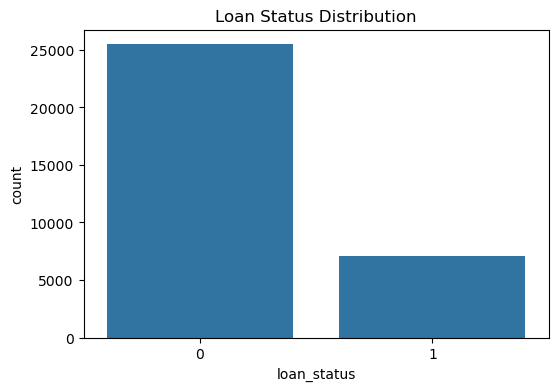

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="loan_status",
    data=df
)

plt.title("Loan Status Distribution")

plt.show()

In [ ]:
numerical_features = ["person_age","person_income","person_emp_length","loan_amnt","loan_int_rate","loan_percent_income","cb_person_cred_hist_length"]

categorical_features = ["person_home_ownership","loan_intent","loan_grade","cb_person_default_on_file"]

target = "loan_status"

In [13]:
print("Numerical Features")
print(numerical_features)

print()

print("Categorical Features")
print(categorical_features)

Numerical Features
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Features
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


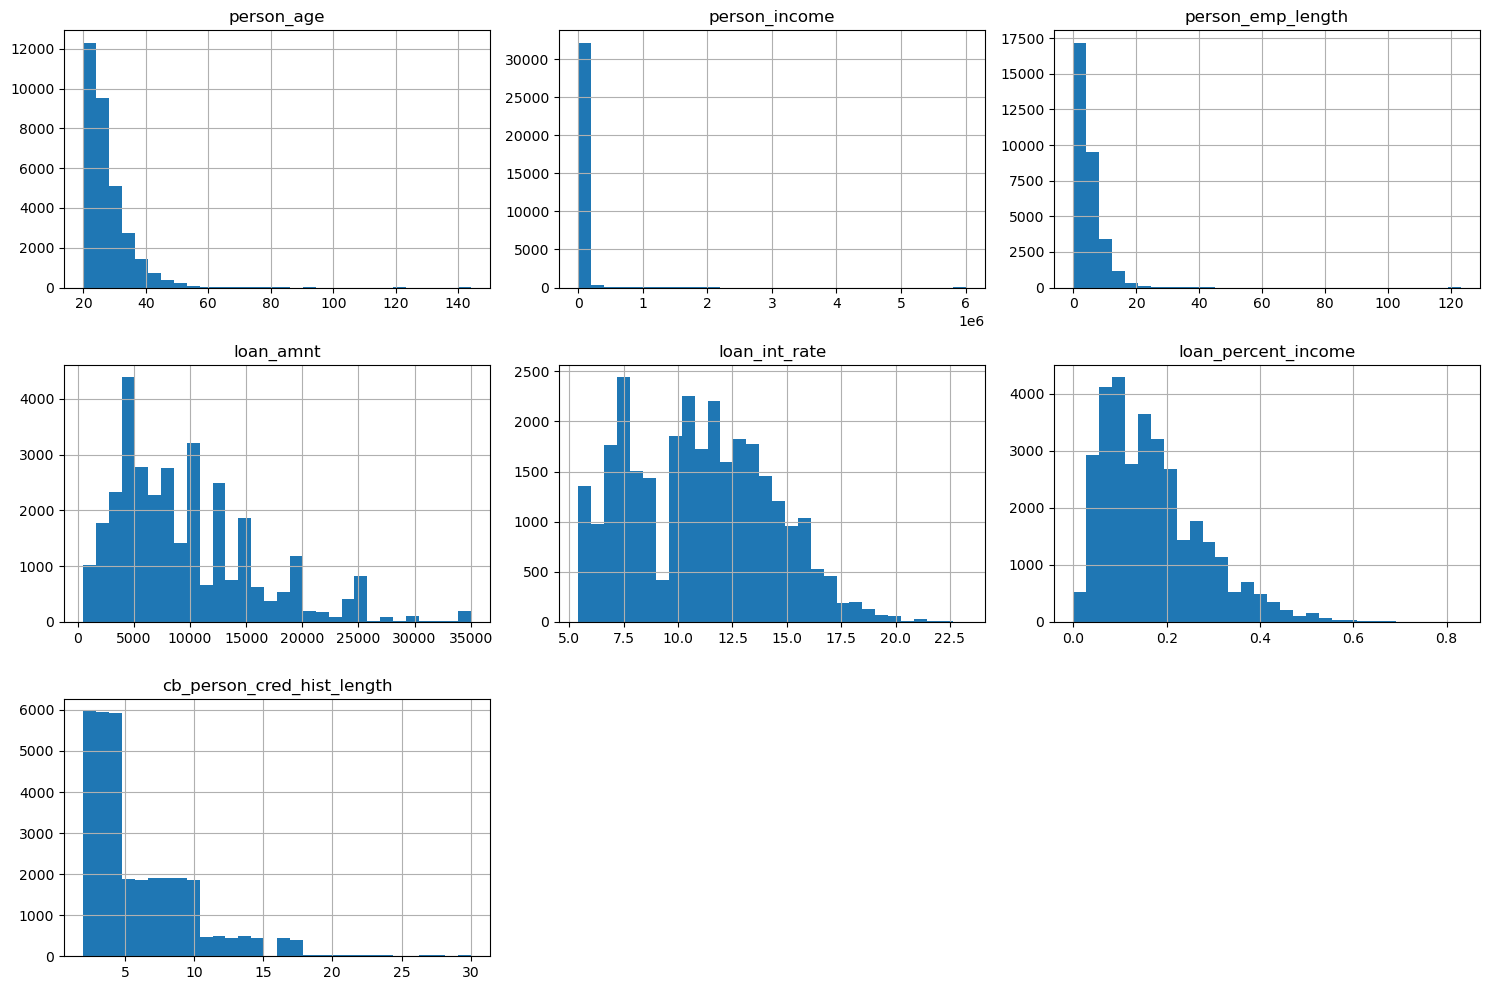

In [ ]:
df[numerical_features].hist(figsize=(15,10),bins=30)
plt.tight_layout()
plt.show()

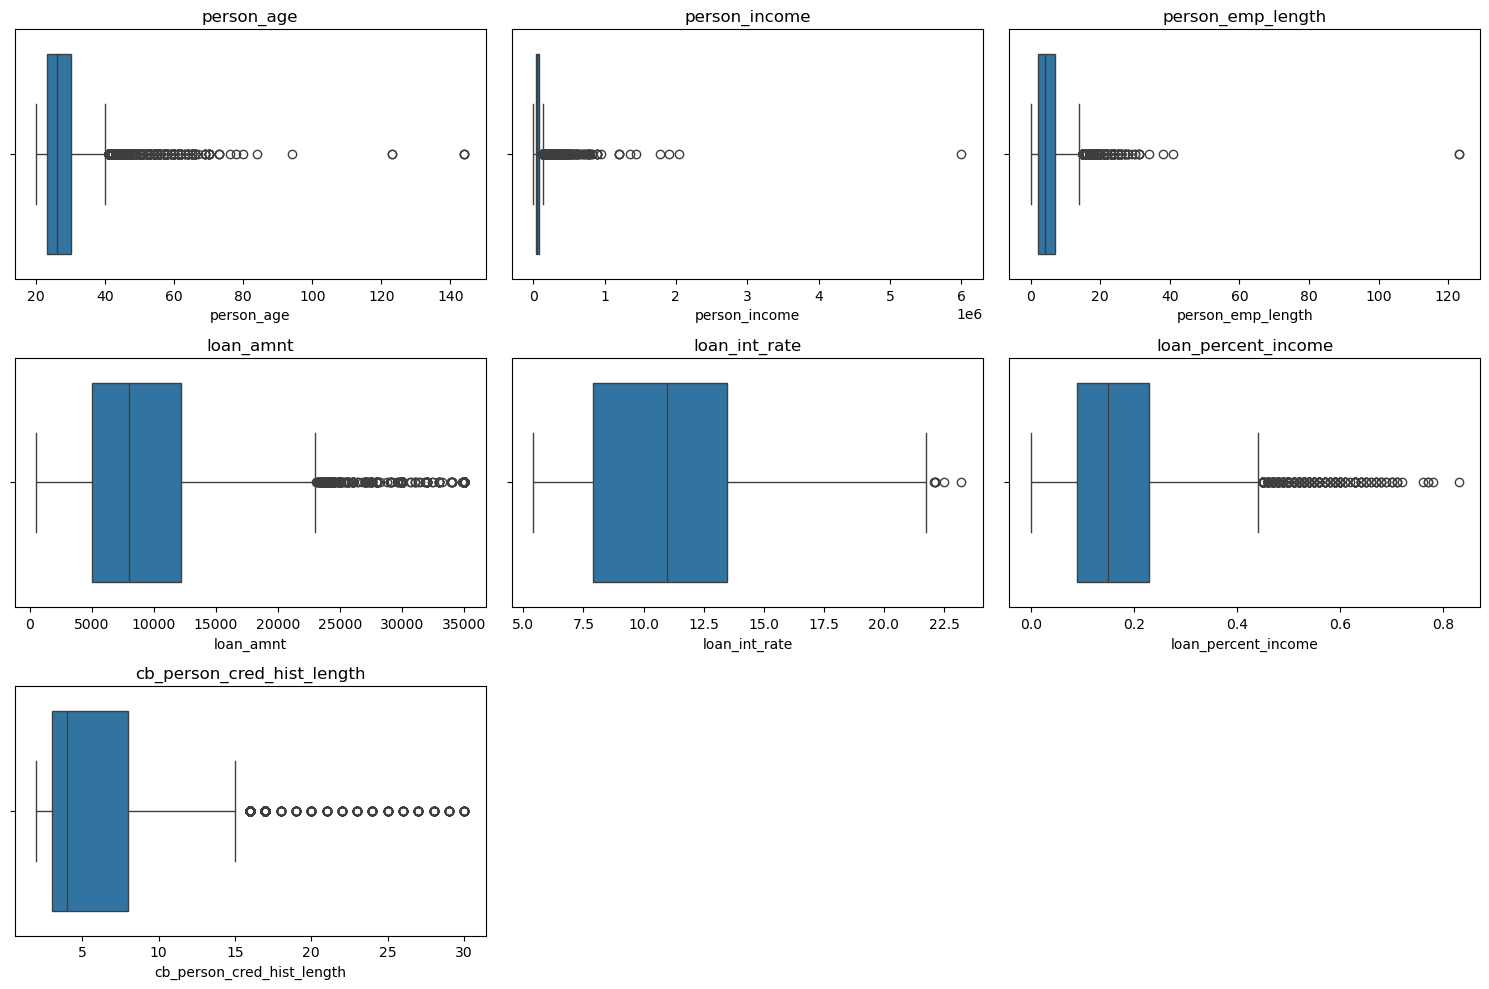

In [ ]:
plt.figure(figsize=(15,10))

for i,col in enumerate(numerical_features,1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [16]:
df["person_age"].describe()

count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

In [ ]:
df[df["person_age"] > 80]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25
32416,94,24000,RENT,1.0,MEDICAL,C,6500,NaN,0,0.27,N,27
32506,84,94800,MORTGAGE,2.0,PERSONAL,A,10000,7.51,0,0.11,N,24


In [18]:
df["person_home_ownership"].value_counts()

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

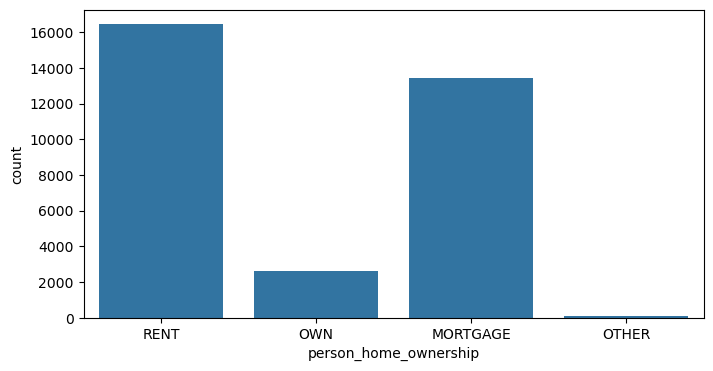

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x="person_home_ownership",data=df)
plt.show()

In [20]:
df["loan_intent"].value_counts()

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

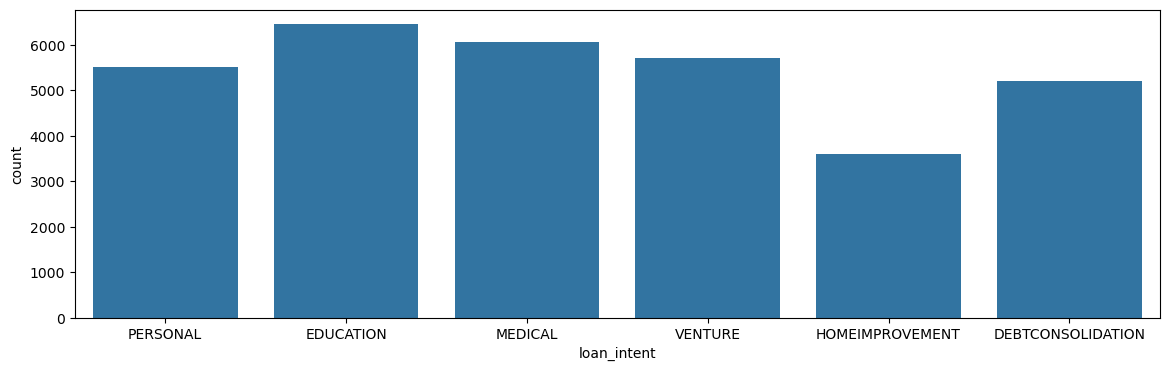

In [ ]:
plt.figure(figsize=(14,4))
sns.countplot(x="loan_intent",data=df)
plt.show()

In [22]:
df["loan_grade"].value_counts()

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

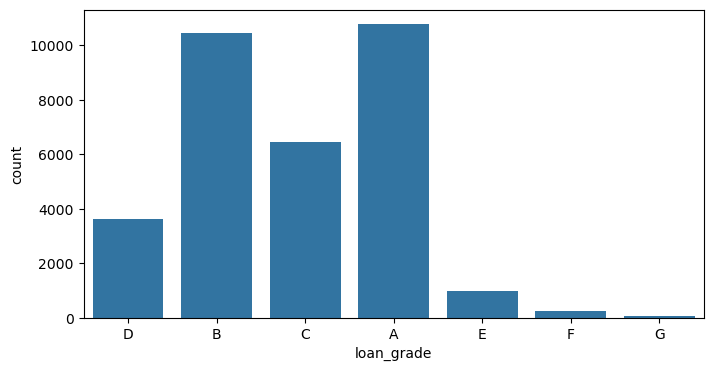

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x="loan_grade",data=df)
plt.show()

In [24]:
df["cb_person_default_on_file"].value_counts()

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

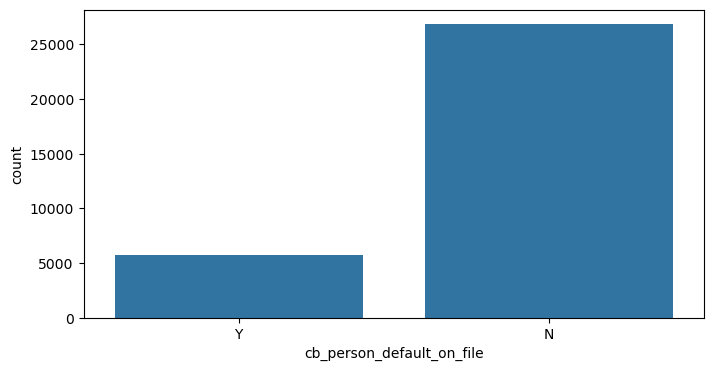

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x="cb_person_default_on_file",data=df)
plt.show()

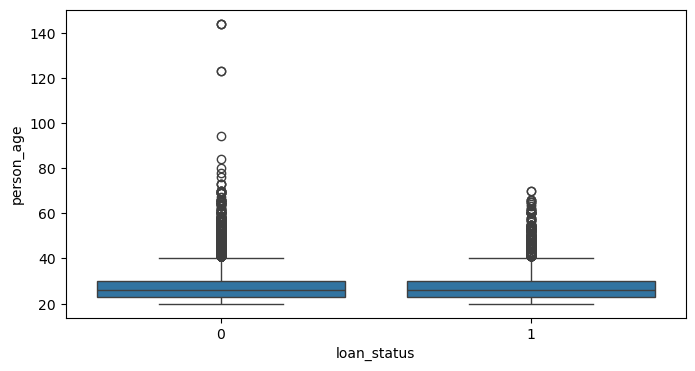

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x="loan_status",y="person_age",data=df)
plt.show()

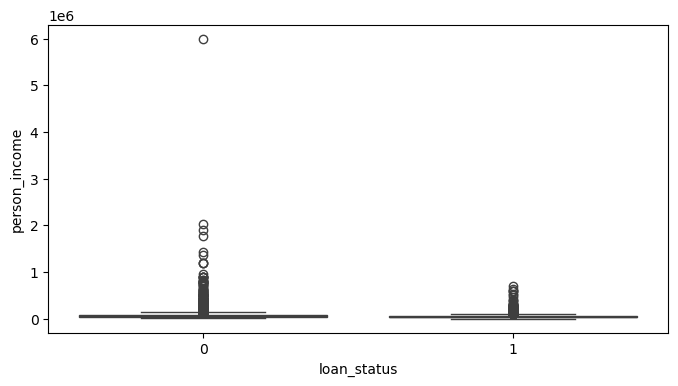

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x="loan_status",y="person_income",data=df)
plt.show()

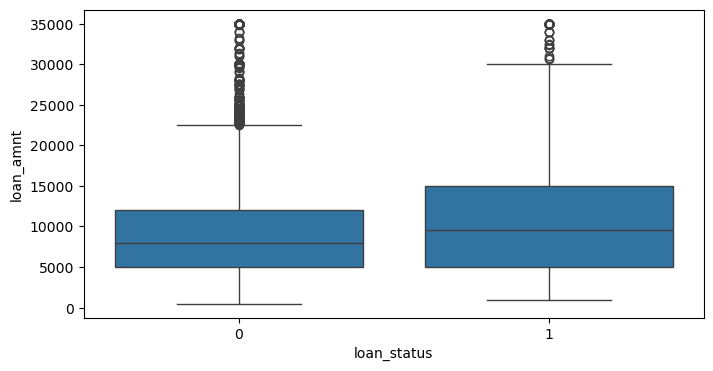

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x="loan_status",y="loan_amnt",data=df)
plt.show()

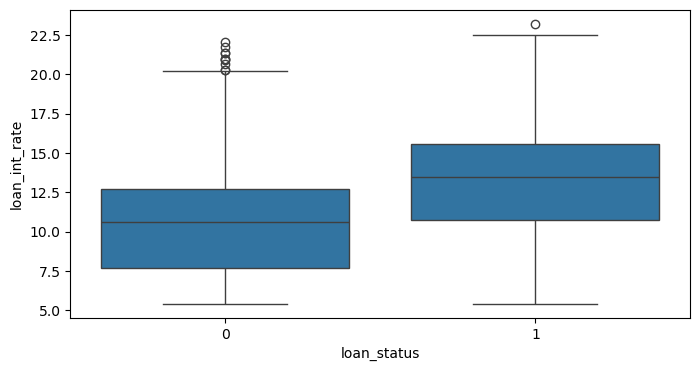

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x="loan_status",y="loan_int_rate",data=df)
plt.show()

In [ ]:
pd.crosstab(df["person_home_ownership"],df["loan_status"],normalize="index")

loan_status,0,1
person_home_ownership,,
MORTGAGE,0.874293,0.125707
OTHER,0.691589,0.308411
OWN,0.925310,0.074690
RENT,0.684300,0.315700


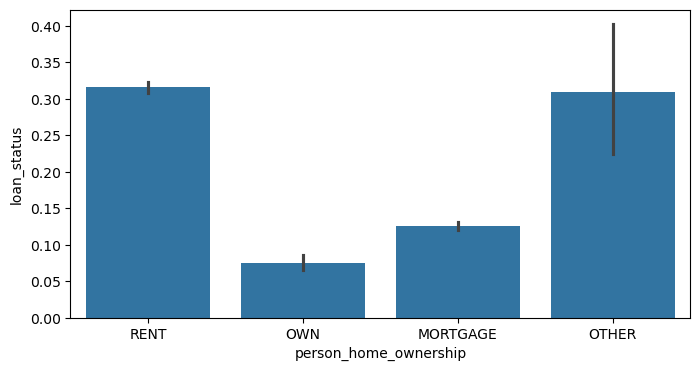

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(x="person_home_ownership",y="loan_status",data=df)
plt.show()

In [ ]:
corr_matrix = df[numerical_features + ["loan_status"]].corr()
corr_matrix

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.042411,0.859133,-0.021629
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.254471,0.117987,-0.144449
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.054111,0.144699,-0.082489
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.572612,0.041967,0.105376
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.120314,0.016696,0.335133
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,1.000000,-0.031690,0.379366
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.031690,1.000000,-0.015529
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,0.379366,-0.015529,1.000000


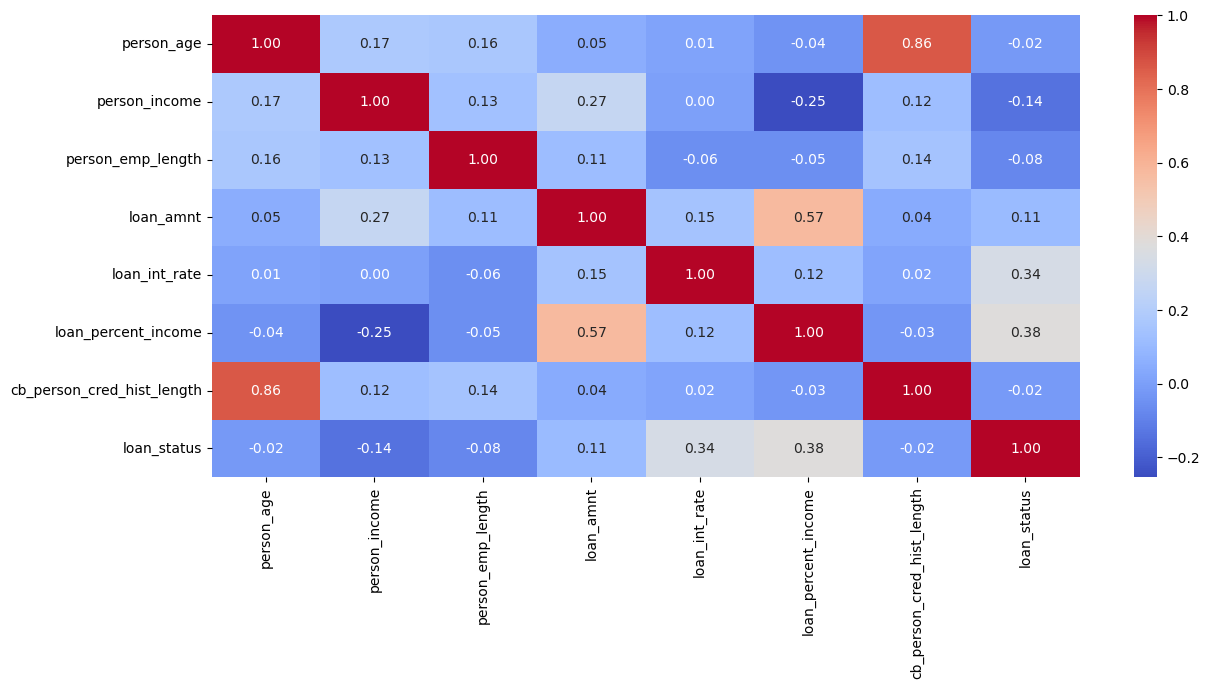

In [ ]:
plt.figure(figsize=(14,6))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

In [34]:
df[["person_emp_length","loan_int_rate"]].isnull().sum()

person_emp_length     895
loan_int_rate        3116
dtype: int64

In [ ]:
(df[["person_emp_length","loan_int_rate"]].isnull().mean()* 100)

person_emp_length    2.747000
loan_int_rate        9.563856
dtype: float64

In [36]:
df["person_emp_length"].describe()

count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

In [37]:
df["loan_int_rate"].describe()

count    29465.000000
mean        11.011695
std          3.240459
min          5.420000
25%          7.900000
50%         10.990000
75%         13.470000
max         23.220000
Name: loan_int_rate, dtype: float64

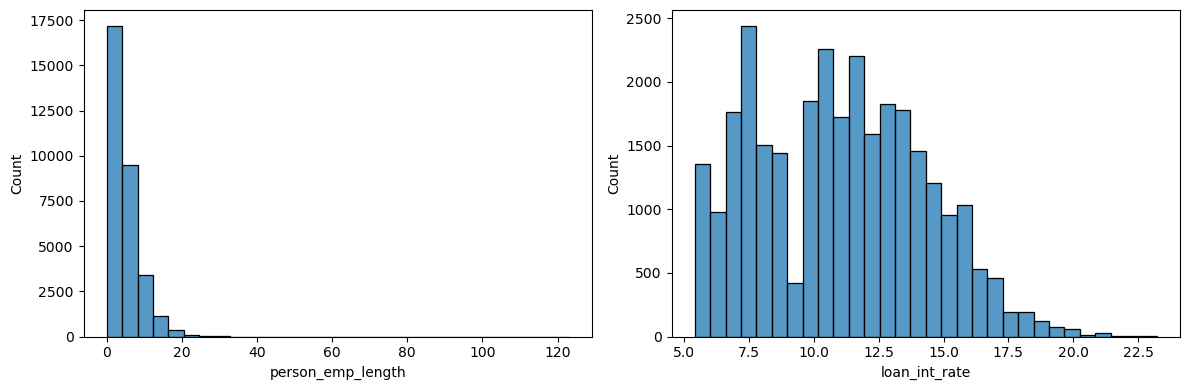

In [38]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df["person_emp_length"], bins=30)

plt.subplot(1,2,2)
sns.histplot(df["loan_int_rate"], bins=30)

plt.tight_layout()
plt.show()

In [39]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [40]:
print(X.shape)
print(y.shape)

(32581, 11)
(32581,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [42]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((26064, 11), (6517, 11), (26064,), (6517,))

In [43]:
print("Original Dataset")
print(df["loan_status"].value_counts(normalize=True) * 100)

print("\nTraining Set")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Set")
print(y_test.value_counts(normalize=True) * 100)

Original Dataset
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

Training Set
loan_status
0    78.184469
1    21.815531
Name: proportion, dtype: float64

Testing Set
loan_status
0    78.180144
1    21.819856
Name: proportion, dtype: float64


In [ ]:
X_train.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              738
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 2501
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [ ]:
X_test.isnull().sum()

person_age                      0
person_income                   0
person_home_ownership           0
person_emp_length             157
loan_intent                     0
loan_grade                      0
loan_amnt                       0
loan_int_rate                 615
loan_percent_income             0
cb_person_default_on_file       0
cb_person_cred_hist_length      0
dtype: int64

In [48]:
from sklearn.impute import SimpleImputer
median_imputer = SimpleImputer(strategy="median")

In [ ]:
median_columns = ["person_emp_length", "loan_int_rate"]

X_train[median_columns] = median_imputer.fit_transform(X_train[median_columns])

In [ ]:
X_test[median_columns] = median_imputer.transform(X_test[median_columns])

In [51]:
print(X_train[median_columns].isnull().sum())
print(X_test[median_columns].isnull().sum())

person_emp_length    0
loan_int_rate        0
dtype: int64
person_emp_length    0
loan_int_rate        0
dtype: int64


In [ ]:
X_train.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

In [ ]:
categorical_columns = ["person_home_ownership","loan_intent","loan_grade","cb_person_default_on_file"]
categorical_columns

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [ ]:
X_train["cb_person_default_on_file"] = X_train["cb_person_default_on_file"].map({"N": 0,"Y": 1})

X_test["cb_person_default_on_file"] = X_test["cb_person_default_on_file"].map({"N": 0,"Y": 1})

In [55]:
X_train["cb_person_default_on_file"].value_counts()

cb_person_default_on_file
0    21453
1     4611
Name: count, dtype: int64

In [56]:
print(sorted(X_train["loan_grade"].unique()))

['A', 'B', 'C', 'D', 'E', 'F', 'G']


In [57]:
grade_mapping = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3,
    "E": 4,
    "F": 5,
    "G": 6
}

In [58]:
X_train["loan_grade"] = X_train["loan_grade"].map(grade_mapping)
X_test["loan_grade"] = X_test["loan_grade"].map(grade_mapping)

In [59]:
X_train["loan_grade"].value_counts().sort_index()

loan_grade
0    8621
1    8326
2    5232
3    2875
4     771
5     195
6      44
Name: count, dtype: int64

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)

In [ ]:
nominal_columns = ["person_home_ownership","loan_intent"]

In [62]:
encoded_train = ohe.fit_transform(X_train[nominal_columns])
encoded_test = ohe.transform(X_test[nominal_columns])

In [63]:
encoded_columns = ohe.get_feature_names_out(nominal_columns)

In [ ]:
encoded_train = pd.DataFrame(encoded_train,columns=encoded_columns,index=X_train.index)

encoded_test = pd.DataFrame(encoded_test,columns=encoded_columns,index=X_test.index)

In [65]:
X_train = X_train.drop(columns=nominal_columns)
X_test = X_test.drop(columns=nominal_columns)

In [66]:
X_train = pd.concat([X_train, encoded_train], axis=1)
X_test = pd.concat([X_test, encoded_test], axis=1)

In [67]:
print(X_train.head())

       person_age  person_income  person_emp_length  loan_grade  loan_amnt  \
15884          25         241875                4.0           0      16000   
15138          21          18000                5.0           1       1500   
7474           25          53000               10.0           1      16000   
18212          28          16800                4.0           2       5000   
6493           25          50000                2.0           0      10000   

       loan_int_rate  loan_percent_income  cb_person_default_on_file  \
15884           7.05                 0.07                          0   
15138          12.18                 0.08                          0   
7474           12.53                 0.30                          0   
18212          13.98                 0.30                          0   
6493            7.90                 0.20                          0   

       cb_person_cred_hist_length  person_home_ownership_OTHER  \
15884                           

In [68]:
print(X_train.shape)
print(X_test.shape)

(26064, 17)
(6517, 17)


In [ ]:
numerical_columns = ["person_age","person_income","person_emp_length","loan_amnt","loan_int_rate","loan_percent_income","cb_person_cred_hist_length"]

numerical_columns

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length']

In [72]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])

In [ ]:
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

In [75]:
X_train[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,26064.0,9.323420e-17,1.000019,-1.217406,-0.743260,-0.269114,0.363080,18.380626
person_income,26064.0,-4.559479e-17,1.000019,-0.973769,-0.433184,-0.173327,0.203352,93.133134
person_emp_length,26064.0,-1.080917e-16,1.000019,-1.159683,-0.673657,-0.187630,0.541409,28.730937
loan_amnt,26064.0,-2.998761e-17,1.000019,-1.440500,-0.725739,-0.249232,0.386112,4.039335
loan_int_rate,26064.0,-2.742503e-16,1.000019,-1.818297,-0.820263,-0.007533,0.681663,3.727778
loan_percent_income,26064.0,-7.987608e-17,1.000019,-1.593354,-0.750700,-0.188930,0.560095,6.177788
cb_person_cred_hist_length,26064.0,-7.524163e-17,1.000019,-0.938514,-0.690666,-0.442817,0.548578,6.001252


In [ ]:
X_train["loan_income_ratio"] = (X_train["loan_amnt"] / X_train["person_income"])

X_test["loan_income_ratio"] = (X_test["loan_amnt"] / X_test["person_income"])

In [ ]:
X_train["income_per_emp_year"] = (X_train["person_income"] /(X_train["person_emp_length"] + 1))

X_test["income_per_emp_year"] = (X_test["person_income"] /(X_test["person_emp_length"] + 1))

In [ ]:
X_train["credit_history_ratio"] = (X_train["cb_person_cred_hist_length"] /X_train["person_age"])

X_test["credit_history_ratio"] = (X_test["cb_person_cred_hist_length"] /X_test["person_age"])

In [ ]:
X_train[["loan_income_ratio","income_per_emp_year","credit_history_ratio"]].head()

,loan_income_ratio,income_per_emp_year,credit_history_ratio
15884,0.370137,3.397057,1.036646
15138,1.699729,-0.714471,0.418005
7474,-4.989594,-0.090166,2.197087
18212,0.939013,-0.951382,11.676144
6493,-0.271801,-0.771586,2.197087


In [ ]:
numerical_columns = ["person_age","person_income","person_emp_length","loan_amnt","loan_int_rate","loan_percent_income",
                     "cb_person_cred_hist_length","loan_income_ratio","income_per_emp_year","credit_history_ratio"]

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])

In [ ]:
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

In [84]:
X_train[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,26064.0,3.816605e-18,1.000019,-1.217406,-0.743260,-0.269114,0.363080,18.380626
person_income,26064.0,-8.314746e-18,1.000019,-0.973769,-0.433184,-0.173327,0.203352,93.133134
person_emp_length,26064.0,-3.203222e-17,1.000019,-1.159683,-0.673657,-0.187630,0.541409,28.730937
loan_amnt,26064.0,-1.581165e-17,1.000019,-1.440500,-0.725739,-0.249232,0.386112,4.039335
loan_int_rate,26064.0,-4.089219e-17,1.000019,-1.818297,-0.820263,-0.007533,0.681663,3.727778
loan_percent_income,26064.0,-1.771995e-17,1.000019,-1.593354,-0.750700,-0.188930,0.560095,6.177788
cb_person_cred_hist_length,26064.0,-7.360595e-18,1.000019,-0.938514,-0.690666,-0.442817,0.548578,6.001252
loan_income_ratio,26064.0,1.363073e-18,1.000019,-35.028896,-0.009152,0.006538,0.020020,17.179160
income_per_emp_year,26064.0,1.158612e-18,1.000019,-53.502390,-0.137206,-0.016151,0.100317,58.925215
credit_history_ratio,26064.0,8.791821e-17,1.000019,-3.244234,-0.212230,-0.078533,0.093436,6.347541
